In [2]:
!pip install sdv

import pandas as pd
from google.colab import drive
import os

# Load the dataset
real_data = pd.read_csv("/content/health_disease_prediction.csv")
real_data.head()
#data cleaning
real_data = real_data.drop_duplicates()
real_data = real_data.dropna()

# Label encode categorical columns including goal
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
real_data['Disease'] = label_encoder.fit_transform(real_data['Disease'])  # Target column


#metadata
from sdv.metadata import Metadata
metadata = Metadata.detect_from_dataframe(
    data=real_data,
    table_name='health_disease_prediction'
)

# train TVAE synthesizer
from sdv.single_table import TVAESynthesizer
synthesizer = TVAESynthesizer(metadata)
synthesizer.fit(real_data)

#generate synthetic data
synthetic_data = synthesizer.sample(num_rows=1500)

# split features & goal
X_synthetic = synthetic_data.drop(['Disease'], axis=1)
y_synthetic = synthetic_data['Disease']

X_real = real_data.drop(['Disease'], axis=1)
y_real = real_data['Disease']

# train test split
from sklearn.model_selection import train_test_split
X_train_synthetic, X_test_synthetic, y_train_synthetic, y_test_synthetic = train_test_split(X_synthetic,
                                       y_synthetic,
                                       test_size=0.3,
                                       random_state=42)
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(X_real, y_real, test_size=0.3, random_state=42)

# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_real = scaler.fit_transform(X_train_real)
X_test_real = scaler.transform(X_test_real)
X_train_synthetic = scaler.transform(X_train_synthetic)
X_test_synthetic = scaler.transform(X_test_synthetic)

# KNN Model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_synthetic, y_train_synthetic)

# Predict on real test data
y_pred_knn = knn_model.predict(X_test_real)

# evaluation of KNN
print("\nKNN Classifier Results:")
print(f"Accuracy: {accuracy_score(y_test_real, y_pred_knn):.2f}")
print(f"Precision: {precision_score(y_test_real, y_pred_knn, average='weighted'):.2f}")
print(f"Recall: {recall_score(y_test_real, y_pred_knn, average='weighted'):.2f}")
print(f"F1 Score: {f1_score(y_test_real, y_pred_knn, average='weighted'):.2f}")
# save to CSV
output_dir = '/content/drive/MyDrive/Durgesh(testing)'
os.makedirs(output_dir, exist_ok=True)
synthetic_data.to_csv(f'{output_dir}/synthetic_data_TVAE.csv', index=False)

/usr/local/lib/python3.11/dist-packages/sdv/single_table/base.py:129: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(



KNN Classifier Results:
Accuracy: 0.66
Precision: 0.58
Recall: 0.66
F1 Score: 0.59


### XGboost classifier & analysed its accuracy on  real test data

In [3]:
# XGBoost classifier
!pip install xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train_synthetic, y_train_synthetic)

#Predict on real test data
y_pred_xgb = xgb_model.predict(X_test_real)

# Evaluation
print("\nXGBoost Classifier Results:")
print(f"Accuracy: {accuracy_score(y_test_real, y_pred_xgb):.2f}")
print(f"Precision: {precision_score(y_test_real, y_pred_xgb, average='weighted'):.2f}")
print(f"Recall: {recall_score(y_test_real, y_pred_xgb, average='weighted'):.2f}")
print(f"F1 Score: {f1_score(y_test_real, y_pred_xgb, average='weighted'):.2f}")


XGBoost Classifier Results:
Accuracy: 0.58
Precision: 0.58
Recall: 0.58
F1 Score: 0.58


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:18:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


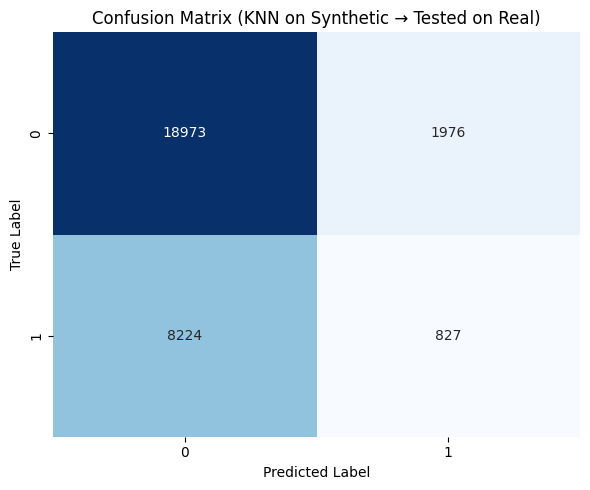

/tmp/ipython-input-4-255777710.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_names, y=metrics, palette='Set2')


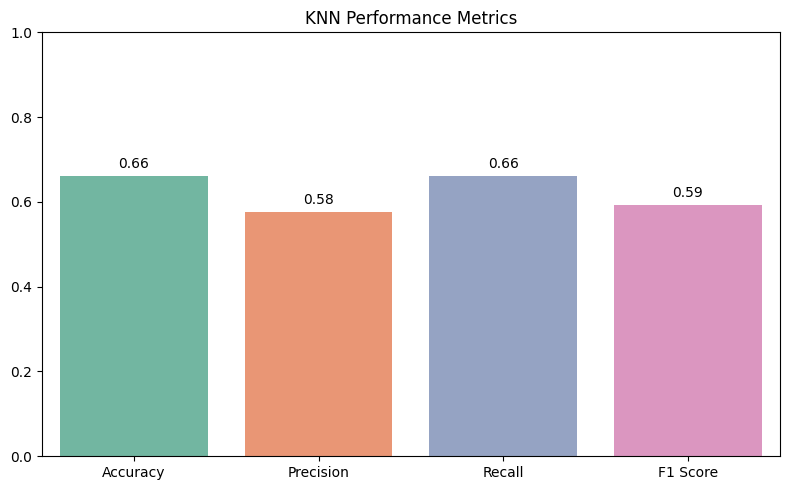

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

#Confusion Matrix Plot
cm = confusion_matrix(y_test_real, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (KNN on Synthetic → Tested on Real)')
plt.tight_layout()
plt.show()


#bar plot of evaluation matrix
accuracy = accuracy_score(y_test_real, y_pred_knn)
precision = precision_score(y_test_real, y_pred_knn, average='weighted')
recall = recall_score(y_test_real, y_pred_knn, average='weighted')
f1 = f1_score(y_test_real, y_pred_knn, average='weighted')

metrics = [accuracy, precision, recall, f1]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(8, 5))
sns.barplot(x=metric_names, y=metrics, palette='Set2')
plt.ylim(0, 1)
plt.title('KNN Performance Metrics')
for i, val in enumerate(metrics):
    plt.text(i, val + 0.02, f"{val:.2f}", ha='center')
plt.tight_layout()
plt.show()
